# 🛍️ Retail EDA: Exploring Our Store Data Step by Step

**What is EDA?**  
EDA is the process of *looking at your data* before building any model — understanding structure, spotting missing values, and finding patterns.

**Datasets we'll use:**
1. `TRANSACTIONS.csv` – Raw daily transaction records
2. `STORES.csv` – Store-level information
3. `CALENDAR.csv` – Date-level flags (weekend, festival, etc.)
4. `final_model_data.csv` – Aggregated store-month data (used for modeling)

---

## Step 1: Import Libraries

- **`pandas`** – data tables (like Excel in Python)
- **`numpy`** – numerical operations
- **`matplotlib / seaborn`** – charts and visualizations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## Step 2: Load the Raw Transactions Data

`pd.read_csv()` loads a CSV file into a **DataFrame** (a table with rows and columns).  
We convert `transaction_date` to a **datetime** format so Python understands it as a date.

In [2]:
transactions = pd.read_csv('raw_data/TRANSACTIONS.csv')
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])
transactions['date'] = transactions['transaction_date'].dt.normalize()  # date only, for joins

print(f"Transactions Shape: {transactions.shape}")

/var/folders/lq/l9_nf9611z552kdf863clz9w0000gp/T/ipykernel_28103/1209223555.py:1: DtypeWarning: Columns (0: promo_id) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv('raw_data/TRANSACTIONS.csv')


Transactions Shape: (6031821, 12)


## Step 3: Load Stores & Calendar Data

In [3]:
stores = pd.read_csv('raw_data/STORES.csv')
print(f"Stores Shape: {stores.shape}")

Stores Shape: (50, 11)


`CALENDAR.csv` has **one row per date** with flags:
- `is_weekend` – True if Saturday/Sunday
- `is_festive_period` – True if a festive day
- `festival_name` – Name of the festival

In [4]:
calendar = pd.read_csv('raw_data/CALENDAR.csv')
calendar['date'] = pd.to_datetime(calendar['date'])

print(f"Calendar Shape: {calendar.shape}")
calendar.head()

Calendar Shape: (1826, 6)


,date,is_weekend,is_festive_period,festival_name,month,year
0,2021-01-01,0,0,NaN,1,2021
1,2021-01-02,1,0,NaN,1,2021
2,2021-01-03,1,0,NaN,1,2021
3,2021-01-04,0,0,NaN,1,2021
4,2021-01-05,0,0,NaN,1,2021


## Step 4: Peek at the Data

`.head()` shows the first 5 rows — a quick first look.

In [5]:
transactions.head()

,transaction_id,store_id,transaction_date,customer_id,gross_bill_value,net_bill_value,total_items,promo_id,promo_discount_amount,payment_mode,category_mix,date
0,DF9EB4D75DE2,STR_001,2021-01-01 16:47:00,NaN,879.15,879.15,1,NaN,0.0,Cash,"{'Menswear': 0.44, 'Womenswear': 0.35, 'Kids':...",2021-01-01
1,EE13BED898BF,STR_001,2021-01-01 14:18:00,CUST_1414,2514.53,2514.53,1,NaN,0.0,Cash,"{'Menswear': 0.27, 'Womenswear': 0.28, 'Kids':...",2021-01-01
2,848A5549A6B4,STR_001,2021-01-01 10:26:00,NaN,6653.94,6653.94,5,NaN,0.0,Cash,"{'Menswear': 0.36, 'Womenswear': 0.27, 'Kids':...",2021-01-01
3,7CE95C5DA9FD,STR_001,2021-01-01 20:24:00,CUST_4995,1388.82,1388.82,1,NaN,0.0,Wallet,"{'Menswear': 0.38, 'Womenswear': 0.26, 'Kids':...",2021-01-01
4,9730BBB93950,STR_001,2021-01-01 13:56:00,NaN,5005.93,5005.93,2,NaN,0.0,Cash,"{'Menswear': 0.24, 'Womenswear': 0.54, 'Kids':...",2021-01-01


In [6]:
stores.head()

,store_id,city,state,location_type,store_format,store_size_sqft,launch_date,competition_density,avg_monthly_footfall,avg_monthly_sales,zone
0,STR_001,Ahmedabad,Gujarat,Rural,Medium High-Street,5000,2018-02-12,5,5457,7442362,West
1,STR_002,Pune,Maharashtra,Suburban,Large Format,10000,2019-12-19,9,7825,11034832,South
2,STR_003,Bangalore,Karnataka,Suburban,Medium High-Street,5000,2015-09-08,8,2577,3089775,West
3,STR_004,Hyderabad,Telangana,Metro,Medium High-Street,5000,2016-10-25,8,4335,3769901,East
4,STR_005,Kolkata,West Bengal,Metro,Medium High-Street,5000,2018-05-29,10,3823,2101394,South


## Step 5: Check Columns and Data Types

`.info()` shows column names, data types, and non-null counts — helps spot missing data.

In [7]:
print("=== TRANSACTIONS INFO ===")
transactions.info()

=== TRANSACTIONS INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 6031821 entries, 0 to 6031820
Data columns (total 12 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   transaction_id         str           
 1   store_id               str           
 2   transaction_date       datetime64[us]
 3   customer_id            str           
 4   gross_bill_value       float64       
 5   net_bill_value         float64       
 6   total_items            int64         
 7   promo_id               str           
 8   promo_discount_amount  float64       
 9   payment_mode           str           
 10  category_mix           str           
 11  date                   datetime64[us]
dtypes: datetime64[us](2), float64(3), int64(1), str(6)
memory usage: 552.2 MB


In [8]:
print("=== STORES INFO ===")
stores.info()

=== STORES INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   store_id              50 non-null     str  
 1   city                  50 non-null     str  
 2   state                 50 non-null     str  
 3   location_type         50 non-null     str  
 4   store_format          50 non-null     str  
 5   store_size_sqft       50 non-null     int64
 6   launch_date           50 non-null     str  
 7   competition_density   50 non-null     int64
 8   avg_monthly_footfall  50 non-null     int64
 9   avg_monthly_sales     50 non-null     int64
 10  zone                  50 non-null     str  
dtypes: int64(4), str(7)
memory usage: 4.4 KB


## Step 6: Check for Missing Values

`.isnull().sum()` counts missing (NaN) values per column.

In [9]:
print("=== TRANSACTIONS ===")
print(transactions.isnull().sum())

=== TRANSACTIONS ===
transaction_id                 0
store_id                       0
transaction_date               0
customer_id              1809476
gross_bill_value               0
net_bill_value                 0
total_items                    0
promo_id                 5495936
promo_discount_amount          0
payment_mode                   0
category_mix                   0
date                           0
dtype: int64


In [10]:
print("=== STORES ===")
print(stores.isnull().sum())

=== STORES ===
store_id                0
city                    0
state                   0
location_type           0
store_format            0
store_size_sqft         0
launch_date             0
competition_density     0
avg_monthly_footfall    0
avg_monthly_sales       0
zone                    0
dtype: int64


## Step 7: Data Integrity Checks

Quick sanity checks before trusting the numbers:
1. Net bill ≤ Gross bill (discount can only reduce price)
2. `gross - net` ≈ `promo_discount_amount`
3. How many transactions are walk-ins (no customer ID)?

In [11]:
pct_ok = (transactions['net_bill_value'] <= transactions['gross_bill_value']).mean() * 100
print(f"✅ Net ≤ Gross on {pct_ok:.1f}% of rows")

diff = transactions['gross_bill_value'] - transactions['net_bill_value']
close = (diff - transactions['promo_discount_amount']).abs() < 1e-3
print(f"✅ Discount consistent on {close.mean()*100:.1f}% of rows")

null_ratio = transactions['customer_id'].isna().mean() * 100
print(f"ℹ️  {null_ratio:.1f}% of transactions have no customer ID (walk-ins)")

✅ Net ≤ Gross on 100.0% of rows
✅ Discount consistent on 97.2% of rows
ℹ️  30.0% of transactions have no customer ID (walk-ins)


## Step 8: Aggregate Daily Sales

One row per transaction → group by date → sum sales per day.  
`groupby` + `sum` + `reset_index` is the standard aggregation pattern.

In [12]:
daily_sales = (
    transactions
    .groupby(transactions['transaction_date'].dt.date)['net_bill_value']
    .sum()
    .reset_index()
)
daily_sales.columns = ['transaction_date', 'net_bill_value']
daily_sales['transaction_date'] = pd.to_datetime(daily_sales['transaction_date'])

print(f"Daily sales table shape: {daily_sales.shape}")
daily_sales.head()

Daily sales table shape: (1826, 2)


,transaction_date,net_bill_value
0,2021-01-01,18886858.94
1,2021-01-02,26432307.17
2,2021-01-03,27725204.63
3,2021-01-04,17531914.06
4,2021-01-05,17693699.59


## Step 9: Plot Daily Sales Trend

A line chart is ideal for trends over time. Look for seasonal spikes (festivals) or overall direction.

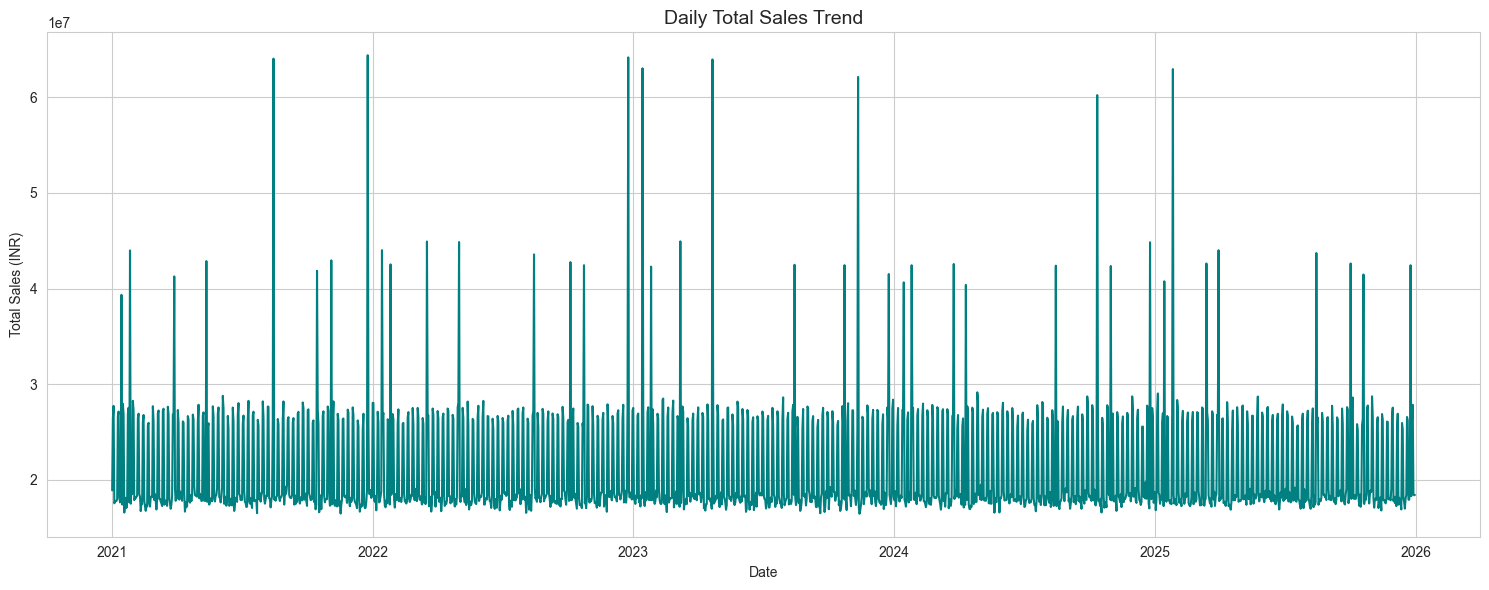

In [13]:
plt.figure(figsize=(15, 6))
sns.lineplot(x='transaction_date', y='net_bill_value', data=daily_sales, color='teal')
plt.title('Daily Total Sales Trend', fontsize=14)
plt.ylabel('Total Sales (INR)')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

## Step 10: Merge Calendar Flags & Build Daily Store Metrics

We attach `is_weekend` and `is_festive_period` to each transaction, then aggregate to a **daily store-level** table.  
We also compute:
- **ATV** = Average Transaction Value (sales ÷ transactions)
- **UPT** = Units Per Transaction (items ÷ transactions)

In [46]:
# Merge calendar flags onto transactions
trx_cal = pd.merge(
    transactions,
    calendar[['date', 'is_weekend', 'is_festive_period', 'festival_name']],
    on='date', how='left'
)
print(f"Merged shape: {trx_cal.shape}")

Merged shape: (6031821, 15)


In [47]:
# Aggregate to daily store-level metrics
daily_store = trx_cal.groupby(['store_id', 'date']).agg(
    total_sales=('net_bill_value', 'sum'),
    total_transactions=('transaction_id', 'count'),
    total_items=('total_items', 'sum'),
    is_weekend=('is_weekend', 'max'),
    is_festive_period=('is_festive_period', 'max')
).reset_index()

daily_store['ATV'] = daily_store['total_sales'] / daily_store['total_transactions']
daily_store['UPT'] = daily_store['total_items'] / daily_store['total_transactions']

daily_store.head()

,store_id,date,total_sales,total_transactions,total_items,is_weekend,is_festive_period,ATV,UPT
0,STR_001,2021-01-01,251482.01,39,130,0,0,6448.256667,3.333333
1,STR_001,2021-01-02,402418.13,69,223,1,0,5832.146812,3.231884
2,STR_001,2021-01-03,507863.88,87,275,1,0,5837.515862,3.160920
3,STR_001,2021-01-04,233032.08,43,142,0,0,5419.350698,3.302326
4,STR_001,2021-01-05,232128.78,46,148,0,0,5046.277826,3.217391


## Step 11: Weekend vs Weekday Behavior

Do customers shop differently on weekends? We compare **Transactions, ATV, and UPT** side by side.

In [52]:
# Robust weekend summary (works for bool/int flags and avoids blank charts).
weekend_map = {0: 'Weekday', 1: 'Weekend', False: 'Weekday', True: 'Weekend'}

weekend_tmp = daily_store.copy()
weekend_tmp['is_weekend'] = pd.to_numeric(weekend_tmp['is_weekend'], errors='coerce')
weekend_tmp = weekend_tmp[weekend_tmp['is_weekend'].isin([0, 1])].copy()
weekend_tmp['is_weekend'] = weekend_tmp['is_weekend'].astype(int)

by_weekend = (
    weekend_tmp
    .groupby('is_weekend')[['total_transactions', 'ATV', 'UPT']]
    .mean()
    .reset_index()
)
by_weekend['is_weekend'] = by_weekend['is_weekend'].map(weekend_map)

# Keep a stable order for plotting.
by_weekend['is_weekend'] = pd.Categorical(by_weekend['is_weekend'], ['Weekday', 'Weekend'], ordered=True)
by_weekend = by_weekend.sort_values('is_weekend').reset_index(drop=True)

print(by_weekend)

  is_weekend  total_transactions          ATV       UPT
0    Weekday           58.029126  6289.180622  3.659439
1    Weekend           86.142605  6285.303019  3.654585


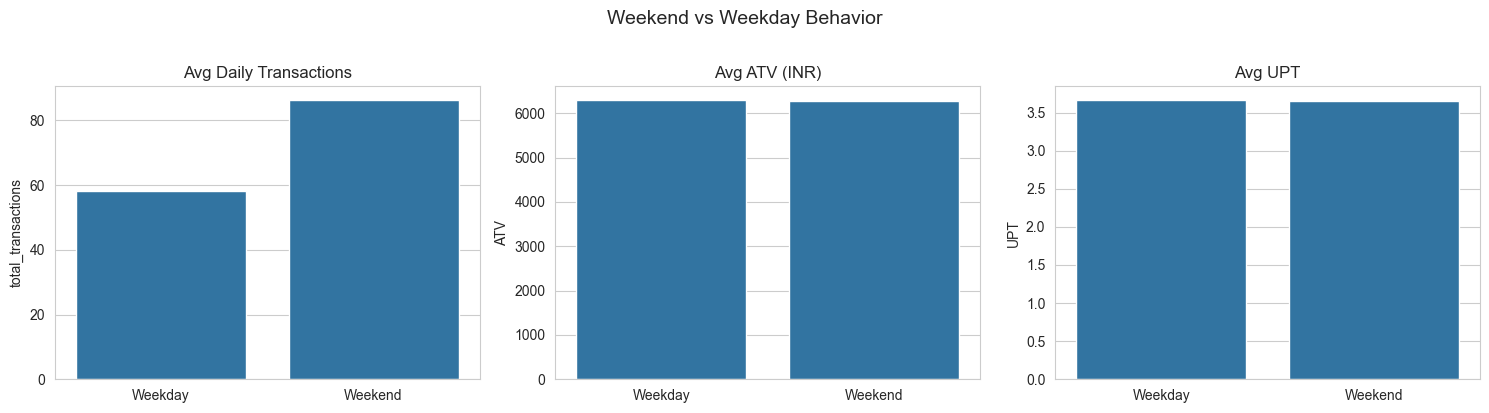

In [53]:
if 'by_weekend' not in globals() or by_weekend.empty:
    weekend_map = {0: 'Weekday', 1: 'Weekend', False: 'Weekday', True: 'Weekend'}
    weekend_tmp = daily_store.copy()
    weekend_tmp['is_weekend'] = pd.to_numeric(weekend_tmp['is_weekend'], errors='coerce')
    weekend_tmp = weekend_tmp[weekend_tmp['is_weekend'].isin([0, 1])].copy()
    weekend_tmp['is_weekend'] = weekend_tmp['is_weekend'].astype(int)
    by_weekend = (
        weekend_tmp
        .groupby('is_weekend')[['total_transactions', 'ATV', 'UPT']]
        .mean()
        .reset_index()
    )
    by_weekend['is_weekend'] = by_weekend['is_weekend'].map(weekend_map)
    by_weekend['is_weekend'] = pd.Categorical(by_weekend['is_weekend'], ['Weekday', 'Weekend'], ordered=True)
    by_weekend = by_weekend.sort_values('is_weekend').reset_index(drop=True)

if by_weekend.empty:
    raise ValueError('Step 11 plot input is empty. Run Step 10 cells first and verify is_weekend values are 0/1.')

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(
    axs,
    ['total_transactions', 'ATV', 'UPT'],
    ['Avg Daily Transactions', 'Avg ATV (INR)', 'Avg UPT']
):
    sns.barplot(data=by_weekend, x='is_weekend', y=col, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')

fig.suptitle('Weekend vs Weekday Behavior', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Step 12: Festival vs Non-Festival Behavior

Festivals (Diwali, Eid, etc.) often drive sales spikes. Same analysis as above, using `is_festive_period`.

In [54]:
# Robust festival summary (works for bool/int flags and avoids blank charts).
festival_map = {0: 'Non-Festival', 1: 'Festival', False: 'Non-Festival', True: 'Festival'}

festival_tmp = daily_store.copy()
festival_tmp['is_festive_period'] = pd.to_numeric(festival_tmp['is_festive_period'], errors='coerce')
festival_tmp = festival_tmp[festival_tmp['is_festive_period'].isin([0, 1])].copy()
festival_tmp['is_festive_period'] = festival_tmp['is_festive_period'].astype(int)

by_festival = (
    festival_tmp
    .groupby('is_festive_period')[['total_transactions', 'ATV', 'UPT']]
    .mean()
    .reset_index()
)
by_festival['is_festive_period'] = by_festival['is_festive_period'].map(festival_map)

# Keep a stable order for plotting.
by_festival['is_festive_period'] = pd.Categorical(by_festival['is_festive_period'], ['Non-Festival', 'Festival'], ordered=True)
by_festival = by_festival.sort_values('is_festive_period').reset_index(drop=True)

print(by_festival)

  is_festive_period  total_transactions          ATV       UPT
0      Non-Festival           64.766092  6261.786180  3.642578
1          Festival          124.104500  7461.739754  4.348960


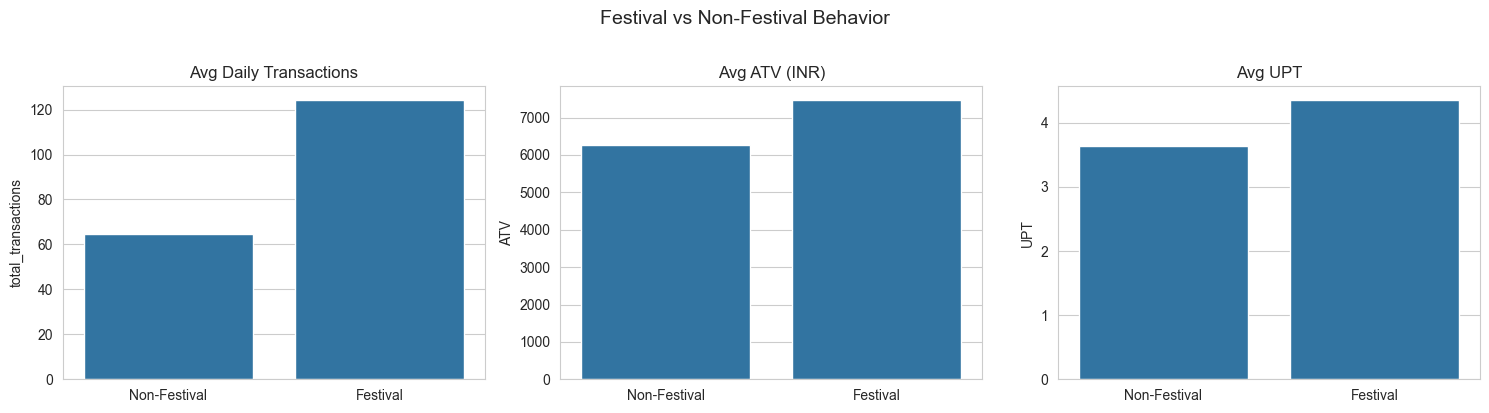

In [55]:
if 'by_festival' not in globals() or by_festival.empty:
    festival_map = {0: 'Non-Festival', 1: 'Festival', False: 'Non-Festival', True: 'Festival'}
    festival_tmp = daily_store.copy()
    festival_tmp['is_festive_period'] = pd.to_numeric(festival_tmp['is_festive_period'], errors='coerce')
    festival_tmp = festival_tmp[festival_tmp['is_festive_period'].isin([0, 1])].copy()
    festival_tmp['is_festive_period'] = festival_tmp['is_festive_period'].astype(int)
    by_festival = (
        festival_tmp
        .groupby('is_festive_period')[['total_transactions', 'ATV', 'UPT']]
        .mean()
        .reset_index()
    )
    by_festival['is_festive_period'] = by_festival['is_festive_period'].map(festival_map)
    by_festival['is_festive_period'] = pd.Categorical(by_festival['is_festive_period'], ['Non-Festival', 'Festival'], ordered=True)
    by_festival = by_festival.sort_values('is_festive_period').reset_index(drop=True)

if by_festival.empty:
    raise ValueError('Step 12 plot input is empty. Run Step 10 cells first and verify is_festive_period values are 0/1.')

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(
    axs,
    ['total_transactions', 'ATV', 'UPT'],
    ['Avg Daily Transactions', 'Avg ATV (INR)', 'Avg UPT']
):
    sns.barplot(data=by_festival, x='is_festive_period', y=col, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('')

fig.suptitle('Festival vs Non-Festival Behavior', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Step 13: Payment Mode by Location Type

We merge transactions with store info to learn if payment preferences vary by **location type** (Tier-1 vs Tier-2 cities).  
Think of `pd.merge` as a VLOOKUP — we match rows using the common key `store_id`.

In [20]:
merged_txns = pd.merge(
    transactions,
    stores[['store_id', 'location_type']],
    on='store_id', how='left'
)
print(f"Merged table shape: {merged_txns.shape}")

Merged table shape: (6031821, 13)


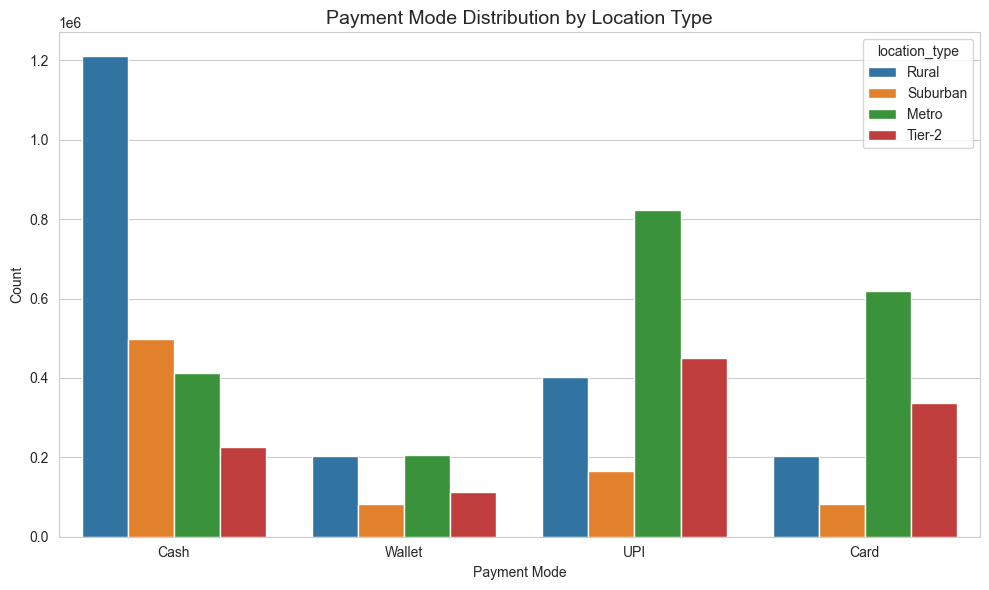

In [21]:
plt.figure(figsize=(10, 6))
sns.countplot(x='payment_mode', hue='location_type', data=merged_txns)
plt.title('Payment Mode Distribution by Location Type', fontsize=14)
plt.xlabel('Payment Mode')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

---
# Part 2: Analyzing the Aggregated (Model-Ready) Data

`final_model_data.csv` is aggregated to **Store-Month** level: one row per store per month.  
This is the format used for building regression models.

## Step 14: Load & Inspect the Final Model Data

In [25]:
# Build model-ready monthly store features from already-loaded raw tables.
base_txn = merged_txns.copy()
base_txn['year'] = base_txn['transaction_date'].dt.year
base_txn['month'] = base_txn['transaction_date'].dt.month

monthly_store = (
    base_txn
    .groupby(['store_id', 'year', 'month'], as_index=False)
    .agg(
        total_sales=('net_bill_value', 'sum'),
        total_transactions=('transaction_id', 'count'),
        total_items=('total_items', 'sum'),
        total_discount=('promo_discount_amount', 'sum')
    )
)

monthly_store['ATV'] = monthly_store['total_sales'] / monthly_store['total_transactions'].replace(0, np.nan)
monthly_store['UPT'] = monthly_store['total_items'] / monthly_store['total_transactions'].replace(0, np.nan)

store_features = [
    'store_id', 'store_format', 'location_type', 'store_size_sqft',
    'competition_density', 'avg_monthly_footfall', 'avg_monthly_sales', 'zone'
]

df = monthly_store.merge(stores[store_features], on='store_id', how='left')

# Derive promo-day features: days each promotion was active in each store-month.
store_promotions = pd.read_csv('raw_data/STORE_PROMOTIONS.csv')
store_promotions['start_date'] = pd.to_datetime(store_promotions['start_date'])
store_promotions['end_date'] = pd.to_datetime(store_promotions['end_date'])
store_promotions['promo_col'] = 'Promo_' + store_promotions['promo_id']

month_windows = df[['store_id', 'year', 'month']].drop_duplicates().copy()
month_windows['month_start'] = pd.to_datetime(dict(year=month_windows['year'], month=month_windows['month'], day=1))
month_windows['month_end'] = month_windows['month_start'] + pd.offsets.MonthEnd(1)

promo_overlap = month_windows.merge(
    store_promotions[['store_id', 'promo_col', 'start_date', 'end_date']],
    on='store_id',
    how='left'
)

promo_overlap = promo_overlap[
    (promo_overlap['start_date'].notna())
    & (promo_overlap['start_date'] <= promo_overlap['month_end'])
    & (promo_overlap['end_date'] >= promo_overlap['month_start'])
].copy()

if not promo_overlap.empty:
    overlap_start = promo_overlap[['start_date', 'month_start']].max(axis=1)
    overlap_end = promo_overlap[['end_date', 'month_end']].min(axis=1)
    promo_overlap['active_days'] = (overlap_end - overlap_start).dt.days + 1
    promo_overlap['active_days'] = promo_overlap['active_days'].clip(lower=0)

    promo_wide = (
        promo_overlap
        .pivot_table(
            index=['store_id', 'year', 'month'],
            columns='promo_col',
            values='active_days',
            aggfunc='sum',
            fill_value=0
        )
        .reset_index()
    )
    df = df.merge(promo_wide, on=['store_id', 'year', 'month'], how='left')

promo_cols = [c for c in df.columns if c.startswith('Promo_')]
if promo_cols:
    df[promo_cols] = df[promo_cols].fillna(0)

print(f"Shape: {df.shape}")
print(f"Derived promotion columns: {len(promo_cols)}")

Shape: (3000, 22)
Derived promotion columns: 6


In [26]:
df.head()

,store_id,year,month,total_sales,total_transactions,total_items,total_discount,ATV,UPT,store_format,location_type,store_size_sqft,competition_density,avg_monthly_footfall,avg_monthly_sales,zone,Promo_PRM_001,Promo_PRM_002,Promo_PRM_003,Promo_PRM_004,Promo_PRM_005,Promo_PRM_006
0,STR_001,2021,1,10126415.82,1919,5831,165983.19,5276.923304,3.038562,Medium High-Street,Rural,5000,5,5457,7442362,West,0.0,0.0,0.0,0.0,0.0,12.0
1,STR_001,2021,2,7777073.88,1539,4712,461209.18,5053.329357,3.061728,Medium High-Street,Rural,5000,5,5457,7442362,West,0.0,12.0,0.0,0.0,0.0,0.0
2,STR_001,2021,3,8928107.61,1722,5204,158711.27,5184.731481,3.022067,Medium High-Street,Rural,5000,5,5457,7442362,West,0.0,0.0,13.0,0.0,0.0,0.0
3,STR_001,2021,4,8882281.60,1630,5059,92714.38,5449.252515,3.103681,Medium High-Street,Rural,5000,5,5457,7442362,West,0.0,0.0,0.0,9.0,0.0,0.0
4,STR_001,2021,5,9471397.20,1814,5590,179034.63,5221.277398,3.081588,Medium High-Street,Rural,5000,5,5457,7442362,West,0.0,0.0,0.0,0.0,15.0,0.0


## Step 15: Summary Statistics

`.describe()` gives count, mean, std, min, max, and quartiles for every numeric column.

In [27]:
df.describe()

,year,month,total_sales,total_transactions,total_items,total_discount,ATV,UPT,store_size_sqft,competition_density,avg_monthly_footfall,avg_monthly_sales,Promo_PRM_001,Promo_PRM_002,Promo_PRM_003,Promo_PRM_004,Promo_PRM_005,Promo_PRM_006
count,3000.000000,3000.000000,3.000000e+03,3000.000000,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000
mean,2023.000000,6.500000,1.280537e+07,2010.607000,7449.709000,2.331746e+05,6310.001984,3.670846,5680.000000,5.920000,5720.380000,5.882894e+06,1.100333,1.18800,1.158333,1.189333,1.119333,1.025667
std,1.414449,3.452628,8.374408e+06,1191.610439,4867.458157,3.819880e+05,728.930029,0.413160,3331.861407,2.883812,3686.486514,4.404996e+06,3.274728,3.42012,3.379606,3.459308,3.318548,3.200691
min,2021.000000,1.000000,3.653022e+06,606.000000,2345.000000,0.000000e+00,4651.441019,2.951176,2000.000000,1.000000,1034.000000,8.305050e+05,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,2022.000000,3.750000,4.965411e+06,724.000000,2875.750000,0.000000e+00,5402.256772,3.115733,2000.000000,3.000000,2701.000000,2.551005e+06,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,2023.000000,6.500000,9.391156e+06,1779.000000,5467.000000,9.610542e+04,6698.306683,3.913473,5000.000000,6.000000,4843.000000,4.235748e+06,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,2024.000000,9.250000,2.313800e+07,3433.250000,13493.750000,2.925140e+05,6873.601044,3.969965,10000.000000,9.000000,7856.000000,8.074260e+06,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
max,2025.000000,12.000000,2.804409e+07,3981.000000,15976.000000,3.061804e+06,7594.199819,4.223108,10000.000000,10.000000,13623.000000,1.817263e+07,16.000000,19.00000,16.000000,16.000000,16.000000,16.000000


In [28]:
print("=== MISSING VALUES ===")
print(df.isnull().sum())

=== MISSING VALUES ===
store_id                0
year                    0
month                   0
total_sales             0
total_transactions      0
total_items             0
total_discount          0
ATV                     0
UPT                     0
store_format            0
location_type           0
store_size_sqft         0
competition_density     0
avg_monthly_footfall    0
avg_monthly_sales       0
zone                    0
Promo_PRM_001           0
Promo_PRM_002           0
Promo_PRM_003           0
Promo_PRM_004           0
Promo_PRM_005           0
Promo_PRM_006           0
dtype: int64


## Step 16: Distribution of the Target Variable – `total_sales`

The **target variable** is what we want to predict.  
A histogram shows whether the data is symmetric or skewed, and if there are any outliers.

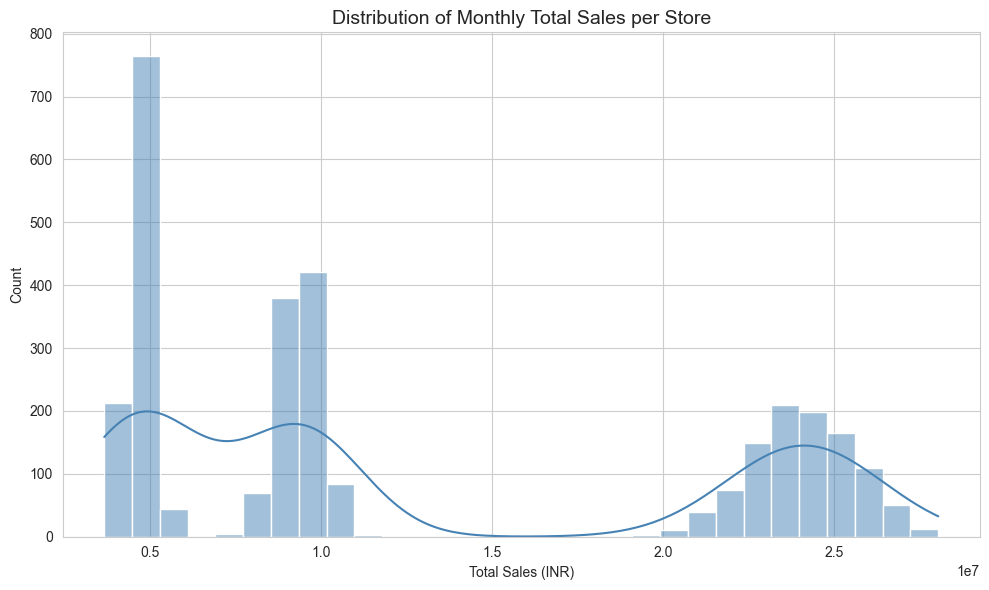

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(df['total_sales'], bins=30, kde=True, color='steelblue')
plt.title('Distribution of Monthly Total Sales per Store', fontsize=14)
plt.xlabel('Total Sales (INR)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Step 17: Monthly Sales Trend (Seasonality)

Are some months consistently higher than others?

In [30]:
monthly_avg = df.groupby('month')['total_sales'].mean().reset_index()
monthly_avg.columns = ['month', 'avg_total_sales']

/var/folders/lq/l9_nf9611z552kdf863clz9w0000gp/T/ipykernel_28103/2973250659.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month', y='avg_total_sales', data=monthly_avg, palette='Blues_d')


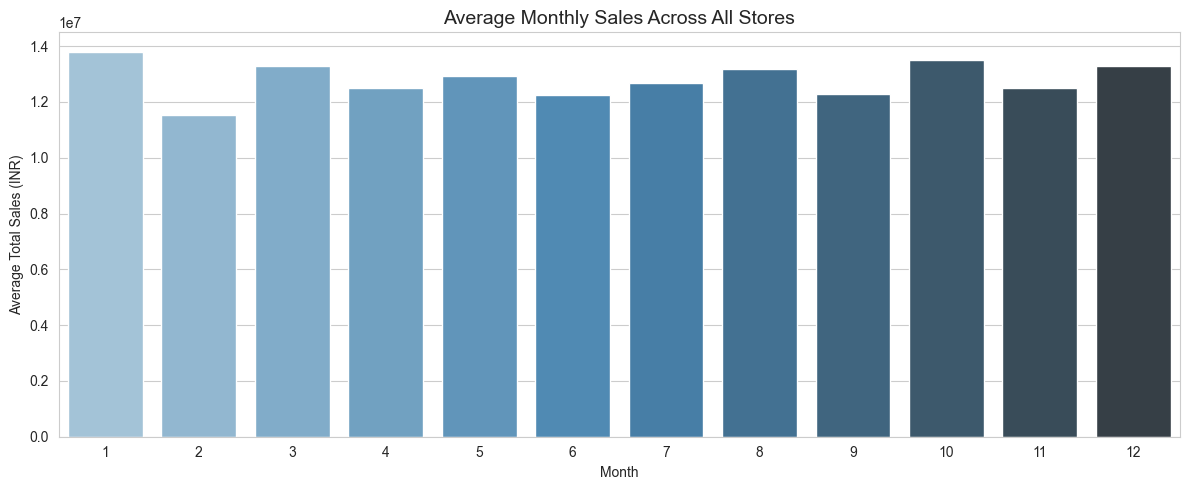

In [31]:
plt.figure(figsize=(12, 5))
sns.barplot(x='month', y='avg_total_sales', data=monthly_avg, palette='Blues_d')
plt.title('Average Monthly Sales Across All Stores', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Average Total Sales (INR)')
plt.tight_layout()
plt.show()

## Step 18: Year-over-Year Seasonality

If data spans multiple years, we compare seasonal patterns using `hue='year'`.  
Do the same months peak every year?

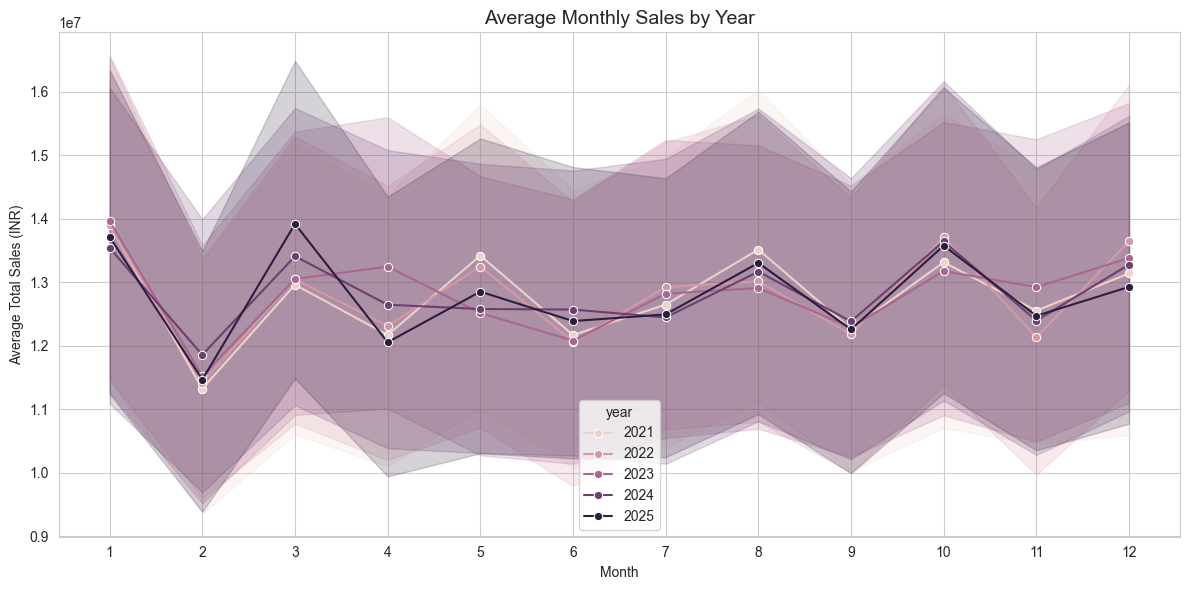

In [32]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='month', y='total_sales', hue='year', estimator='mean', marker='o')
plt.title('Average Monthly Sales by Year', fontsize=14)
plt.xticks(ticks=range(1, 13))
plt.xlabel('Month')
plt.ylabel('Average Total Sales (INR)')
plt.tight_layout()
plt.show()

## Step 19: Sales by Store Format & Location Type

A **box plot** shows the median, spread, and outliers for each group.

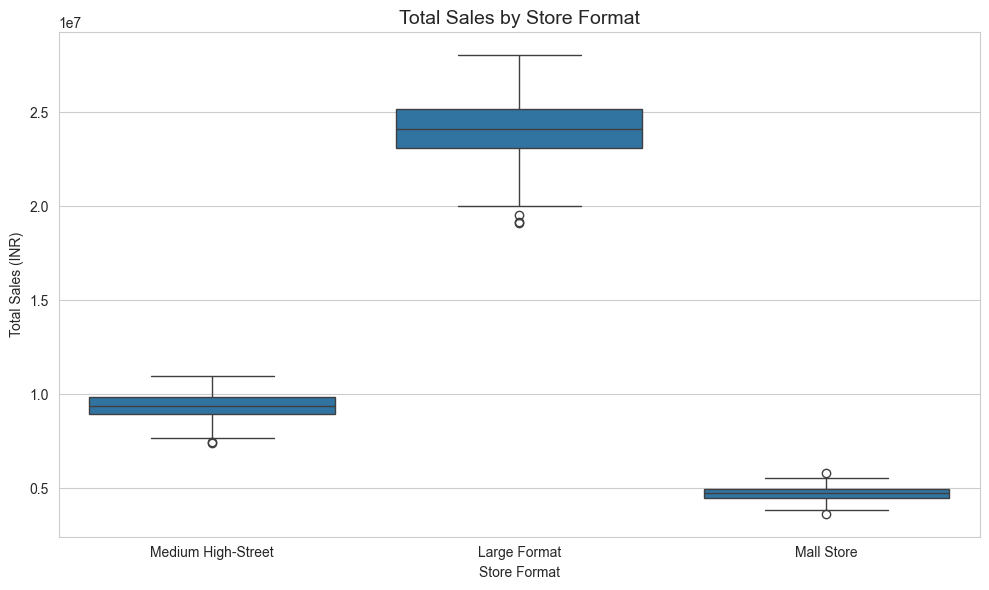

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='store_format', y='total_sales', data=df)
plt.title('Total Sales by Store Format', fontsize=14)
plt.xlabel('Store Format')
plt.ylabel('Total Sales (INR)')
plt.tight_layout()
plt.show()

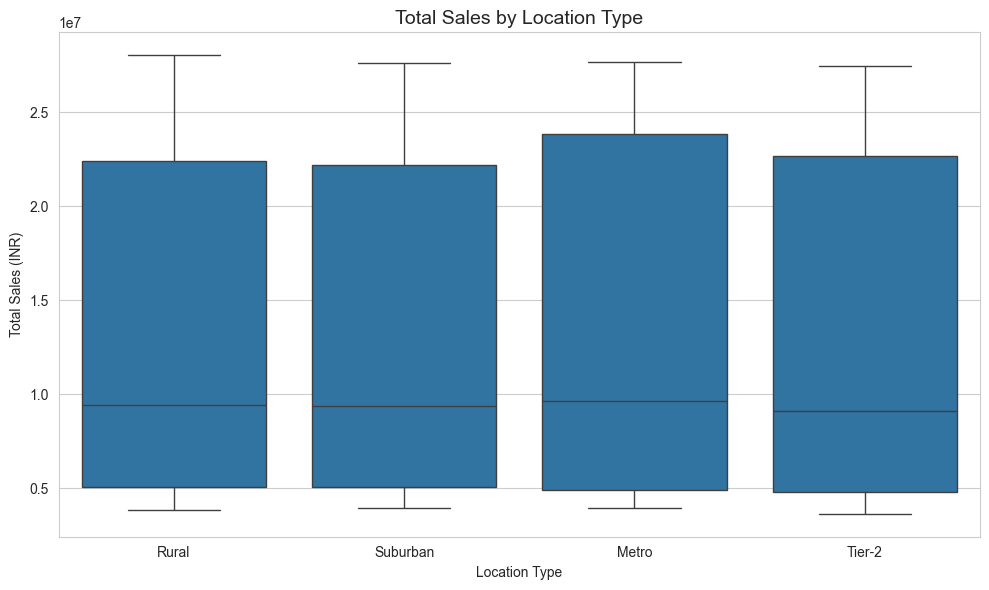

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='location_type', y='total_sales', data=df)
plt.title('Total Sales by Location Type', fontsize=14)
plt.xlabel('Location Type')
plt.ylabel('Total Sales (INR)')
plt.tight_layout()
plt.show()

## Step 20: Sales vs Store Size

A scatter plot with `hue='store_format'` shows if bigger stores sell more, and whether different formats cluster separately.

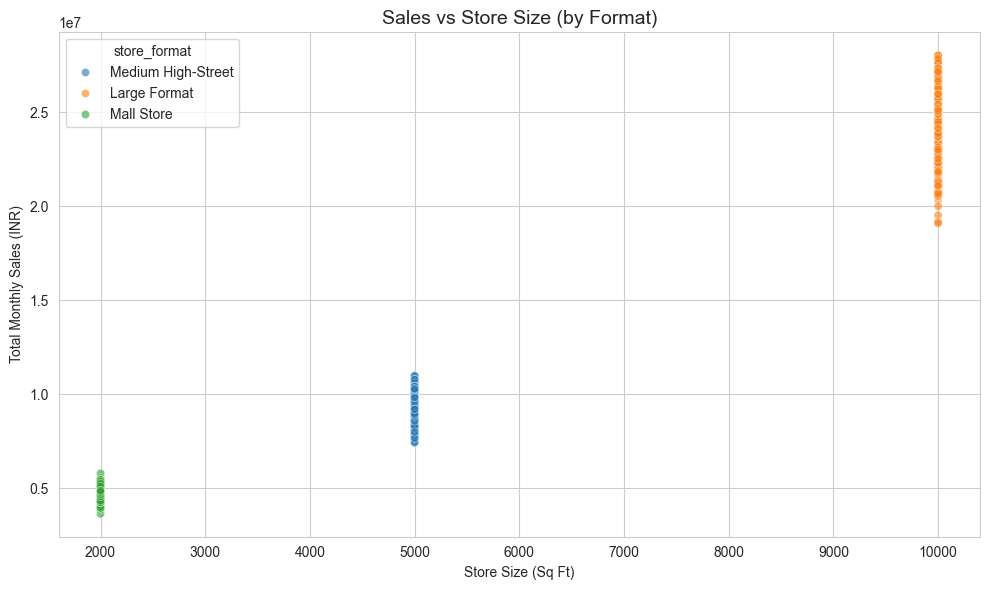

In [35]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='store_size_sqft', y='total_sales', hue='store_format', alpha=0.6, ax=ax)
ax.set_title('Sales vs Store Size (by Format)', fontsize=14)
ax.set_xlabel('Store Size (Sq Ft)')
ax.set_ylabel('Total Monthly Sales (INR)')
plt.tight_layout()
plt.show()

## Step 21: Correlation Heatmap

Correlation tells how strongly two variables move together (+1 = same direction, -1 = opposite, 0 = no link).  
A heatmap shows all pairs at once.

In [36]:
corr_cols = [
    'total_sales', 'total_transactions', 'total_items',
    'total_discount', 'store_size_sqft', 'competition_density',
    'avg_monthly_footfall', 'ATV'
]
corr_matrix = df[corr_cols].corr()

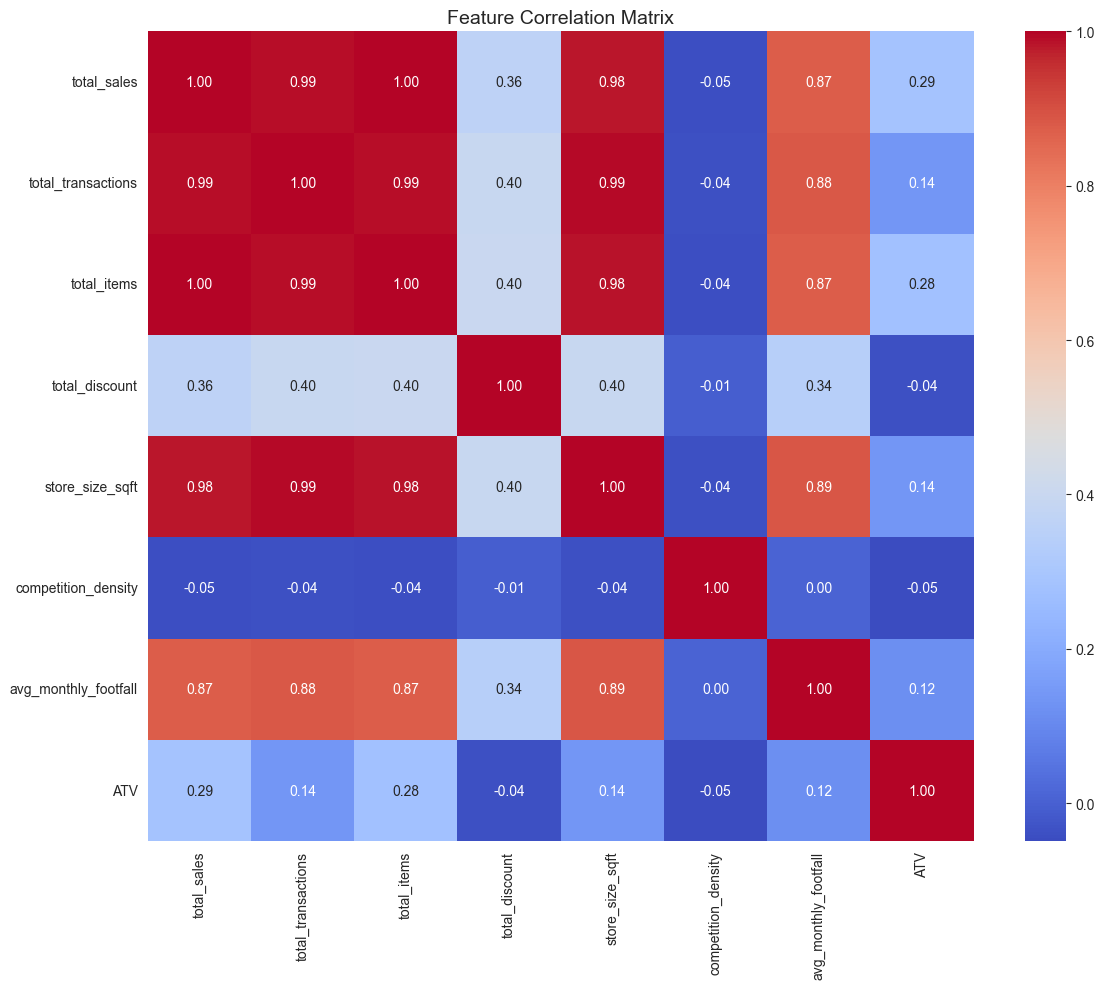

In [37]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

---
# Part 3: Advanced Pattern Analysis

## Step 22: Sales by Day of Week

Extract the day name from the date and compare sales across all 7 days.

In [38]:
daily_sales['day_of_week'] = daily_sales['transaction_date'].dt.day_name()
daily_sales['is_weekend'] = daily_sales['transaction_date'].dt.dayofweek >= 5

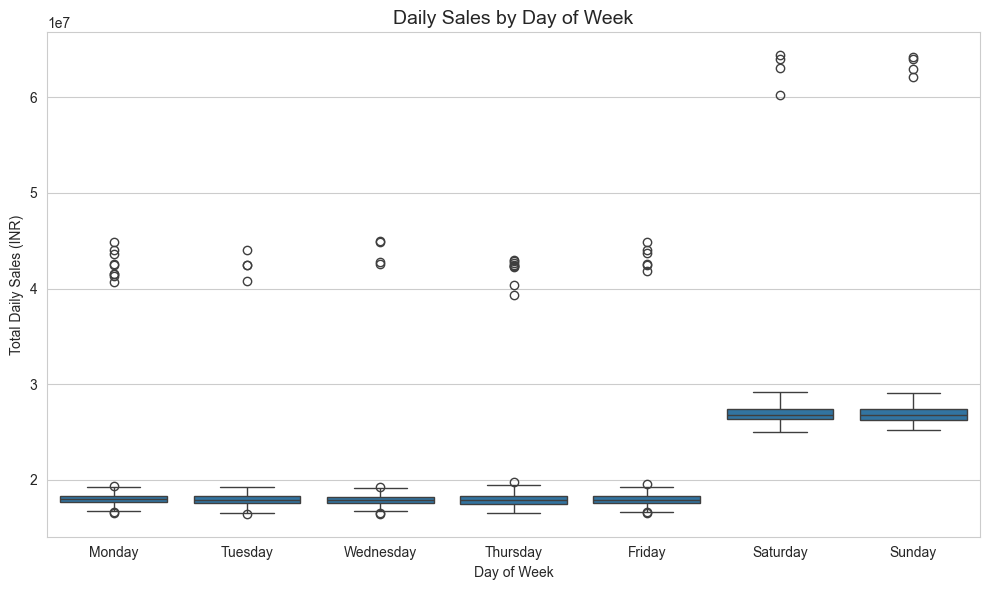

In [39]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 6))
sns.boxplot(x='day_of_week', y='net_bill_value', data=daily_sales, order=day_order)
plt.title('Daily Sales by Day of Week', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Total Daily Sales (INR)')
plt.tight_layout()
plt.show()

## Step 23: Distribution of Store Sizes

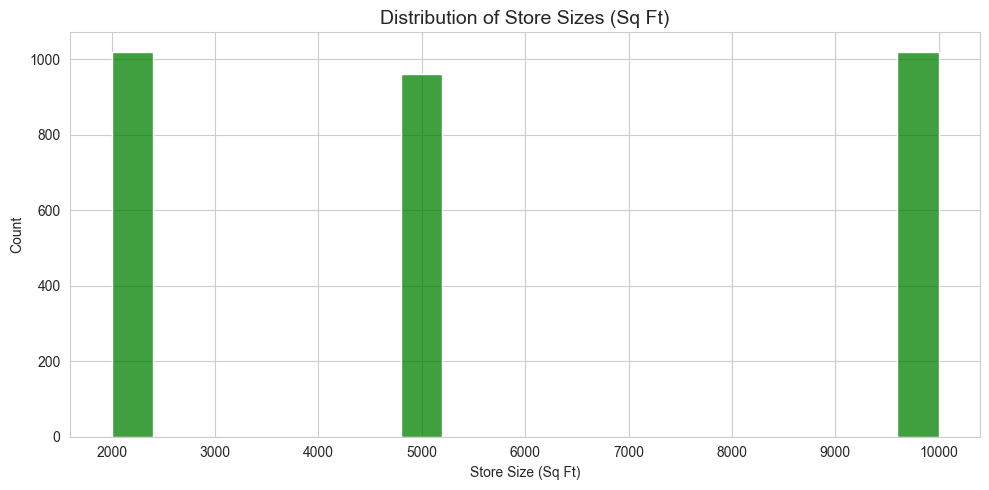

In [40]:
plt.figure(figsize=(10, 5))
sns.histplot(df['store_size_sqft'], bins=20, color='green')
plt.title('Distribution of Store Sizes (Sq Ft)', fontsize=14)
plt.xlabel('Store Size (Sq Ft)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Step 24: Average Transaction Value (ATV) by Store Format

**ATV = Total Sales ÷ Total Transactions** — how much a customer spends per visit.

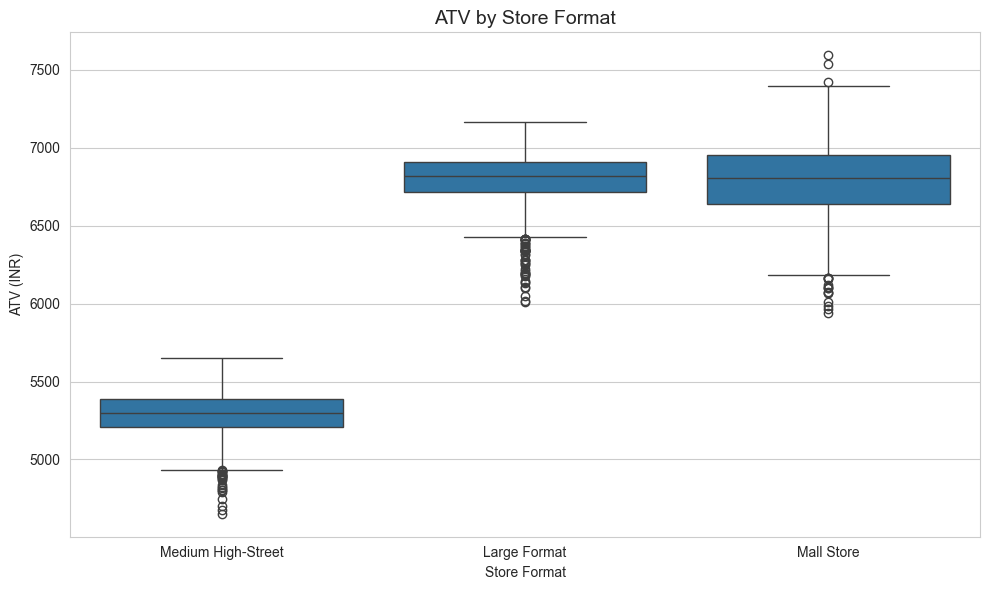

In [41]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='store_format', y='ATV', data=df)
plt.title('ATV by Store Format', fontsize=14)
plt.xlabel('Store Format')
plt.ylabel('ATV (INR)')
plt.tight_layout()
plt.show()

## Step 25: Promotion Analysis

Each `Promo_*` column counts **how many days** that promotion was active in the month.  
We sum all promo columns to get total active promotion days per store-month.

In [42]:
promo_cols = [col for col in df.columns if col.startswith('Promo_')]
print(f"Promotion columns ({len(promo_cols)}): {promo_cols}")

Promotion columns (6): ['Promo_PRM_001', 'Promo_PRM_002', 'Promo_PRM_003', 'Promo_PRM_004', 'Promo_PRM_005', 'Promo_PRM_006']


In [43]:
df['total_active_promo_days'] = df[promo_cols].sum(axis=1)

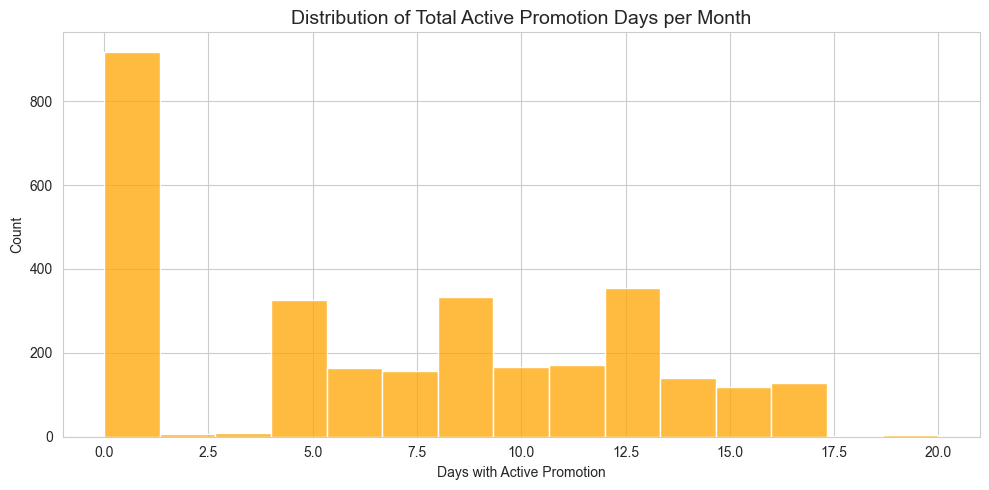

In [44]:
plt.figure(figsize=(10, 5))
sns.histplot(df['total_active_promo_days'], bins=15, kde=False, color='orange')
plt.title('Distribution of Total Active Promotion Days per Month', fontsize=14)
plt.xlabel('Days with Active Promotion')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [45]:
months_with_promo = (df['total_active_promo_days'] > 0).mean() * 100
print(f"Store-months with at least one active promotion: {months_with_promo:.1f}%")

Store-months with at least one active promotion: 69.7%
